## ベイズ回帰モデルによる効果検証

| 項目名 | 説明 | 項目値 |
| :-- | :-- | :-- |
| score | 能力テストのスコア(目的変数) | 0-144の整数 |
| male | 性別 | 1/0 |
| siblings | 世帯内の兄弟数 | 非負整数値 |
| family_inv | 家族の関与の指標 | 0-4の整数値 |
| non_english | 家族での主な言語が英語でないか | True/False |
| prev_disab | 以前の障害の存在 | 1/0 |
| age_test | テスト時の年齢(月単位) | 48-59の整数 |
| non_severe_h1 | 重度の難聴でないか | 1/0 |
| mother_hs | 被験者の母親が高校卒業以上の学歴を持っているか | 1/0 |
| early_ident | 聴覚障害が3ヶ月までに特定されたか | True/False |
| non_white | 非白人 | True/False |

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib
import pandas as pd
from IPython.display import display
import seaborn as sns
np.set_printoptions(precision=3, floatmode='fixed')
plt.rcParams["font.size"] = 14
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams["axes.grid"] = True
pd.options.display.float_format = "{:.3f}".format
pd.set_option("display.max_columns", None)

from pprint import pprint

import pymc as pm
import arviz as az

print(f"Running on PyMC v{pm.__version__}")
print(f"Running on ArviZ v{az.__version__}")

/home/inoue/MyGithub/Book_BayesInference/.venv/lib/python3.12/site-packages/arviz/__init__.py:39: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Running on PyMC v5.27.0
Running on ArviZ v0.23.0


In [2]:
# LSL-DR データ読み込み
df = pd.read_csv(pm.get_data('test_scores.csv'), index_col=0)

display(df.head())

,score,male,siblings,family_inv,non_english,prev_disab,age_test,non_severe_hl,mother_hs,early_ident,non_white
0,40,0,2.000,2.000,False,NaN,55,1.000,NaN,False,False
1,31,1,0.000,NaN,False,0.000,53,0.000,0.000,False,False
2,83,1,1.000,1.000,True,0.000,52,1.000,NaN,False,True
3,75,0,3.000,NaN,False,0.000,55,0.000,1.000,False,False
5,62,0,0.000,4.000,False,1.000,50,0.000,NaN,False,False


データの可視化

([<matplotlib.axis.XTick at 0x79e1400e2fc0>,
 [Text(0, 0, '0'),
  Text(10, 0, '10'),
  Text(20, 0, '20'),
  Text(30, 0, '30'),
  Text(40, 0, '40'),
  Text(50, 0, '50'),
  Text(60, 0, '60'),
  Text(70, 0, '70'),
  Text(80, 0, '80'),
  Text(90, 0, '90'),
  Text(100, 0, '100'),
  Text(110, 0, '110'),
  Text(120, 0, '120'),
  Text(130, 0, '130'),
  Text(140, 0, '140')])

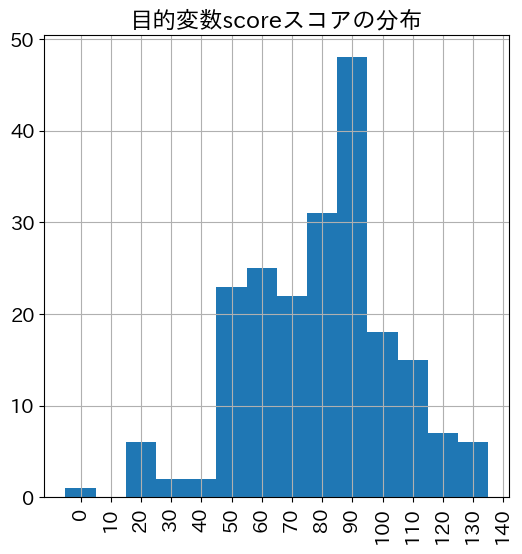

In [3]:
bins = np.arange(0,150,10)
fig, ax = plt.subplots()
df['score'].hist(bins=bins, align='left')
plt.setp(ax.get_xticklabels(), rotation=90)
plt.title('目的変数scoreスコアの分布')
plt.xticks(bins)


統計情報の確認

In [4]:
df.describe()

,score,male,siblings,family_inv,prev_disab,age_test,non_severe_hl,mother_hs
count,207.000,207.000,207.000,174.000,189.000,207.000,207.000,134.000
mean,84.193,0.512,1.126,0.977,0.238,53.546,0.415,0.701
std,24.886,0.501,0.867,1.003,0.427,3.632,0.494,0.459
min,0.000,0.000,0.000,0.000,0.000,48.000,0.000,0.000
25%,68.000,0.000,1.000,0.000,0.000,50.000,0.000,0.000
50%,87.000,1.000,1.000,1.000,0.000,54.000,0.000,1.000
75%,98.000,1.000,2.000,2.000,0.000,57.000,1.000,1.000
max,144.000,1.000,3.000,4.000,1.000,59.000,1.000,1.000


In [5]:
# データ件数と欠損値の確認
print(f'データ件数{len(df)}\n')

# 欠損値の確認
print(df.isnull().sum())

データ件数207

score             0
male              0
siblings          0
family_inv       33
non_english       0
prev_disab       18
age_test          0
non_severe_hl     0
mother_hs        73
early_ident       0
non_white         0
dtype: int64


データ加工

In [6]:
# 欠損値除去
df1 = df.dropna().astype(float)

# データ件数
print(f'データ件数 {len(df1)}\n')

データ件数 101



目的変数yと説明変数Xへの分離

In [7]:
y = df1.pop('score')
X = df1.copy()

# Xの結果確認
display(X.head())

,male,siblings,family_inv,non_english,prev_disab,age_test,non_severe_hl,mother_hs,early_ident,non_white
7,0.000,2.000,3.000,1.000,1.000,50.000,1.000,1.000,0.000,1.000
12,1.000,1.000,0.000,0.000,0.000,48.000,1.000,1.000,1.000,0.000
14,0.000,2.000,0.000,0.000,0.000,58.000,1.000,1.000,1.000,1.000
19,1.000,0.000,2.000,0.000,0.000,50.000,1.000,1.000,0.000,1.000
21,1.000,1.000,2.000,0.000,1.000,58.000,0.000,0.000,1.000,1.000


正規化(標準化)

In [8]:
# Z = (X -E[X]) / std[X]
X -= X.mean()
X /= X.std()

display(X.head())

,male,siblings,family_inv,non_english,prev_disab,age_test,non_severe_hl,mother_hs,early_ident,non_white
7,-1.005,1.078,2.228,2.480,1.782,-0.978,1.179,0.616,-0.773,1.133
12,0.985,-0.080,-0.912,-0.399,-0.556,-1.562,1.179,0.616,1.281,-0.874
14,-1.005,1.078,-0.912,-0.399,-0.556,1.360,1.179,0.616,1.281,1.133
19,0.985,-1.239,1.181,-0.399,-0.556,-0.978,1.179,0.616,-0.773,1.133
21,0.985,-0.080,1.181,-0.399,1.782,1.360,-0.840,-1.607,1.281,1.133


ベイズモデル構築に必要な変数定義

In [10]:
# データ件数とデータ項目数の設定
N, D = X.shape

# 項目名一覧をcolumnsに設定する
columns = X.columns.values
# columns

print(f'N: {N} (データ件数)')
print(f'D: {D} (説明変数項目数)')
print(f'項目名一覧: {columns}')

N: 101 (データ件数)
D: 10 (説明変数項目数)
項目名一覧: ['male' 'siblings' 'family_inv' 'non_english' 'prev_disab' 'age_test'
 'non_severe_hl' 'mother_hs' 'early_ident' 'non_white']


確率モデルの定義
$$y_{n} = \bold{\alpha} \cdot \bold{X}^{T}_{n} + \beta + \epsilon_{n}$$

半正規分布(pm.HalfNormal)
$$f(x) = \sqrt{\frac{2}{\pi \sigma^2}}\exp(-\frac{x^2}{2\sigma^2})$$

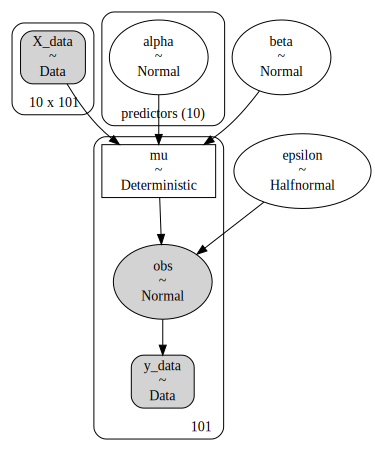

In [ ]:
# 説明変数リストをpredictorsとして定義
model1 = pm.Model(coords={'predictors': columns})

with model1:
    X_data = pm.Data('X_data', X.T)
    y_data = pm.Data('y_data', y)
    alpha = pm.Normal('alpha', mu=0.0, sigma=10.0, dims='predictors') # 事前分布は正規分布
    beta = pm.Normal('beta', mu=100.0, sigma=25.0)
    epsilon = pm.HalfNormal('epsilon', sigma=25.0) # 半正規分布

    # yのモデル予測
    mu = pm.Deterministic('mu', alpha @ X_data + beta)

    # ノイズを含んだ観測値(尤度)
    obs = pm.Normal('obs', mu=mu, sigma=epsilon, observed=y_data)

g = pm.model_to_graphviz(model1)
display(g)

サンプリングと結果分析

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, epsilon]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


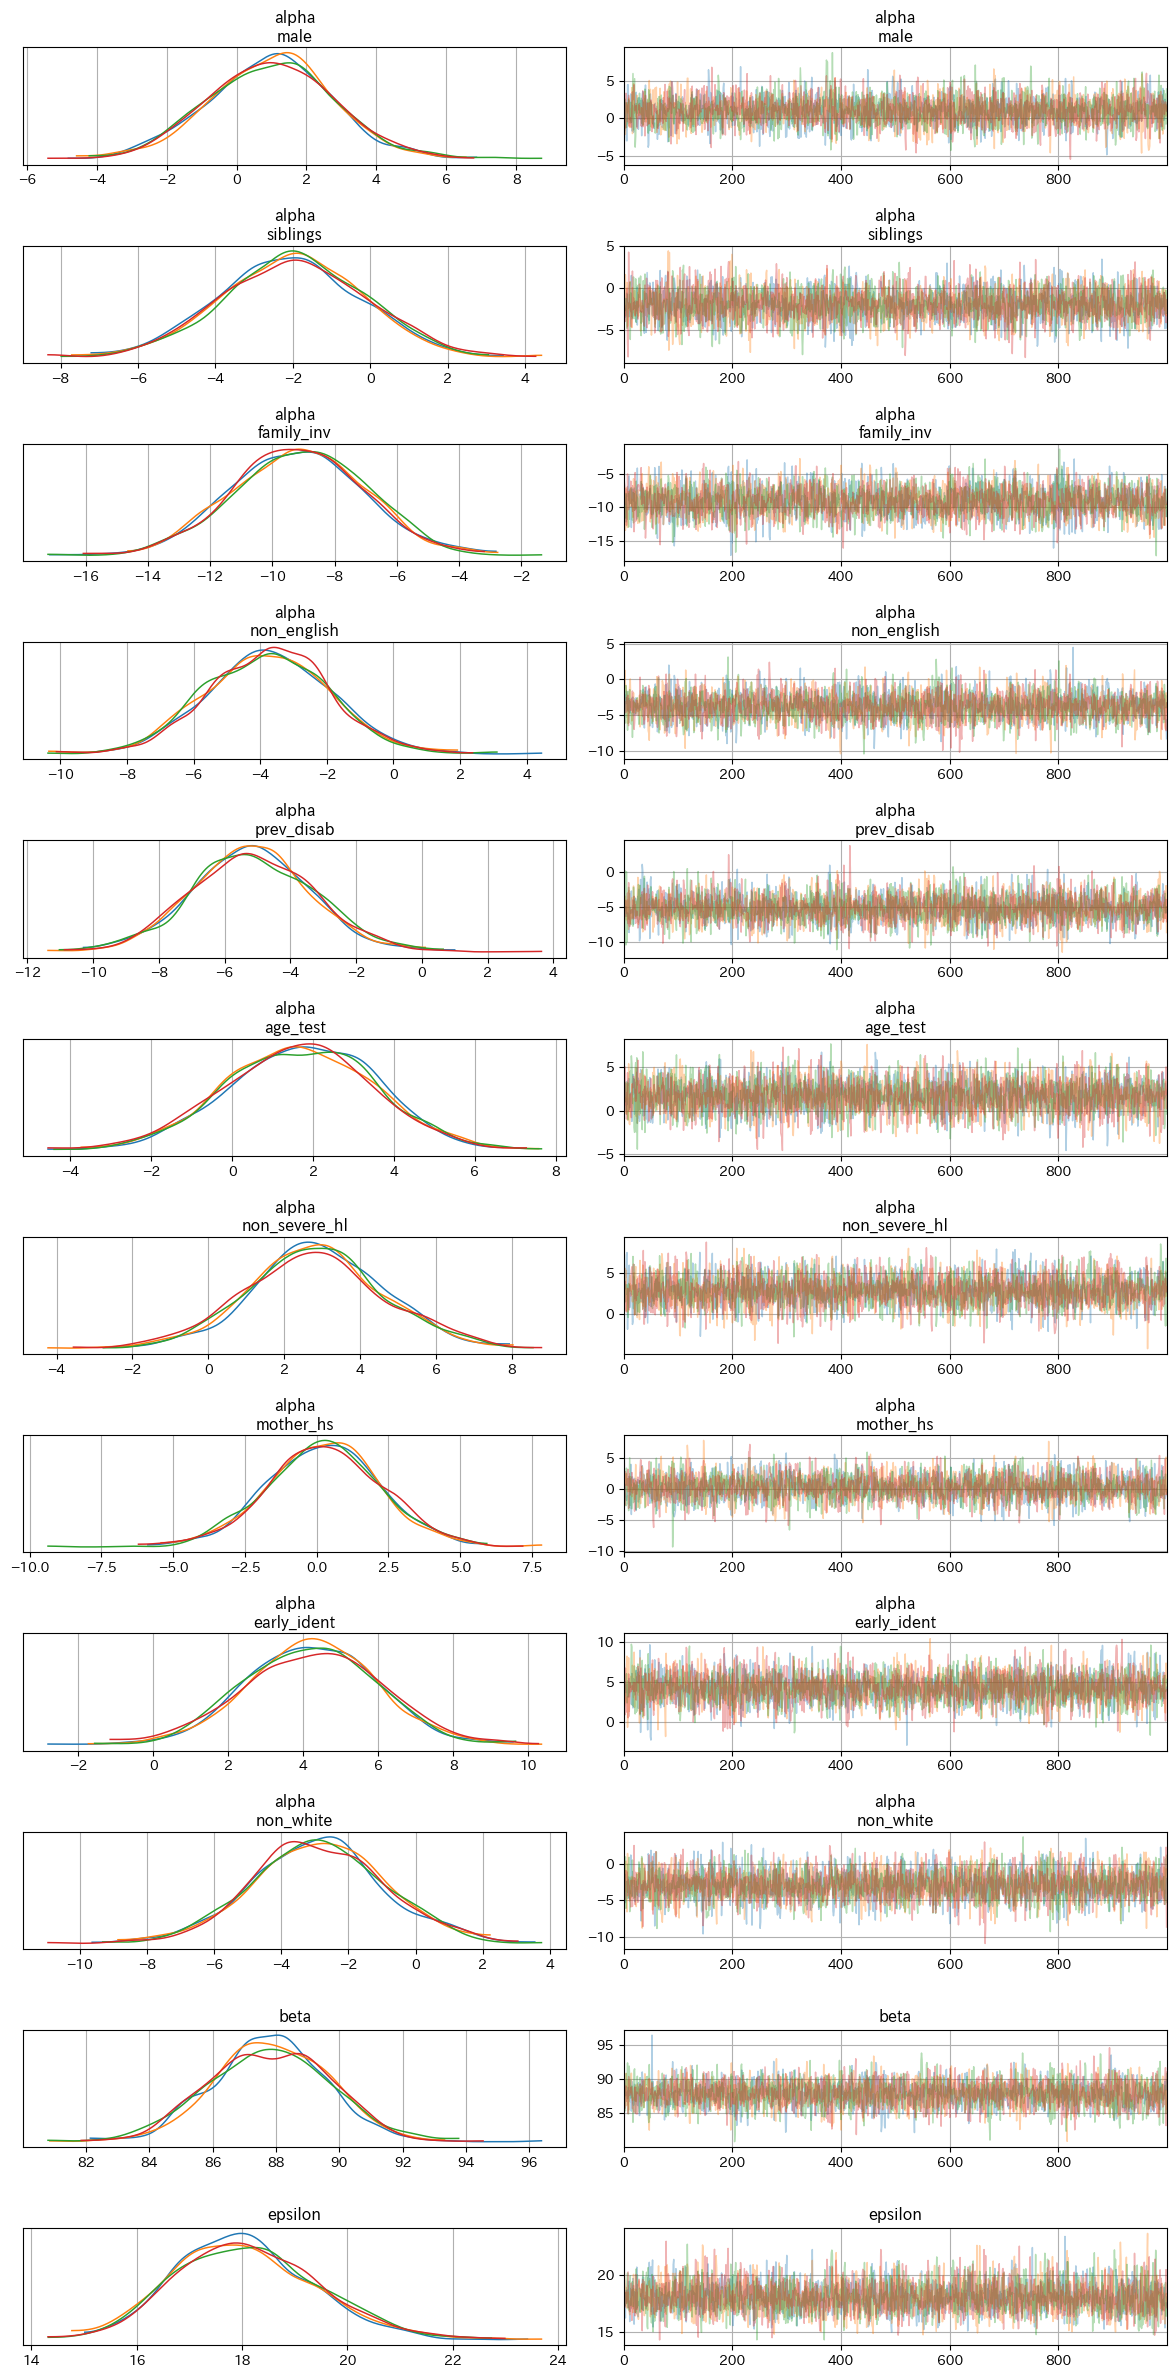

In [14]:
with model1:
    idata1 = pm.sample(random_seed=42, target_accept=0.95)

az.plot_trace(idata1, var_names=['alpha', 'beta', 'epsilon'], compact=False)
plt.tight_layout()

In [15]:
summary1 = az.summary(idata1, var_names=['alpha'])
display(summary1)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[male],0.998,1.796,-2.514,4.263,0.027,0.032,4499.000,2856.000,1.000
alpha[siblings],-2.008,1.823,-5.294,1.472,0.028,0.027,4288.000,3219.000,1.000
alpha[family_inv],-9.139,2.111,-13.013,-5.207,0.036,0.028,3497.000,3317.000,1.000
alpha[non_english],-3.759,1.852,-7.081,-0.286,0.029,0.029,4094.000,3037.000,1.000
alpha[prev_disab],-5.156,1.858,-8.706,-1.703,0.028,0.031,4534.000,2839.000,1.000
alpha[age_test],1.677,1.831,-1.666,5.127,0.028,0.028,4420.000,3258.000,1.000
alpha[non_severe_hl],2.838,1.793,-0.693,6.160,0.027,0.030,4423.000,3095.000,1.000
alpha[mother_hs],0.259,1.974,-3.216,4.295,0.033,0.032,3558.000,2764.000,1.000
alpha[early_ident],4.223,1.783,0.758,7.365,0.026,0.030,4731.000,3081.000,1.000
alpha[non_white],-2.907,1.968,-6.530,0.949,0.029,0.031,4601.000,2837.000,1.000


array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

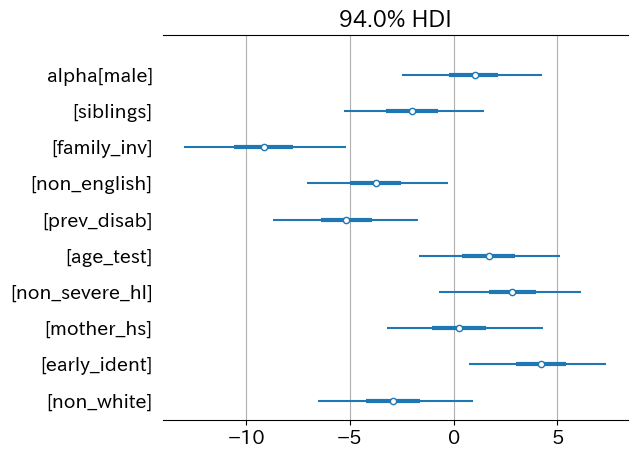

In [16]:
az.plot_forest(idata1, combined=True, var_names=['alpha'])